# 1. Introduction

## 1.1 Genomic prediction and polygenic scores (PGSs)

**What are PGSs and why are they interesting?**

A growing area withing human genetics is the examining how well can we predict human traits, such as cholesterol levels or disease risk, from genetic data alone. This is interesting from a biological perspective (how much of this trait is genetic? in what manner do the genetics influence this trait?) as well as for the clinic (can we identify high risk individuals before symptoms appear?). 

The current approach to this is using a polygenic score (PGS), which is a single number summarizing the total/combined effect of multiple genetic variants on a single trait.

*Some terminology:*

- **PGS (polygenic score)**: Generally used as the umbrella term that can be applied to any trait, whether continuous (HDL cholesterol, BMI, height) or binary (coronary artery disease, type 2 diabetes, eye color).
- **PRS (polygenic risk score)**: Generally referes specifically to *disease risk*.

It's useful to be aware of both of these terms as they both appear in the literature, and are often used interchangeably (e.g. sometimes you might see PRS used to refer to height, which is perhaps not 100% precise).

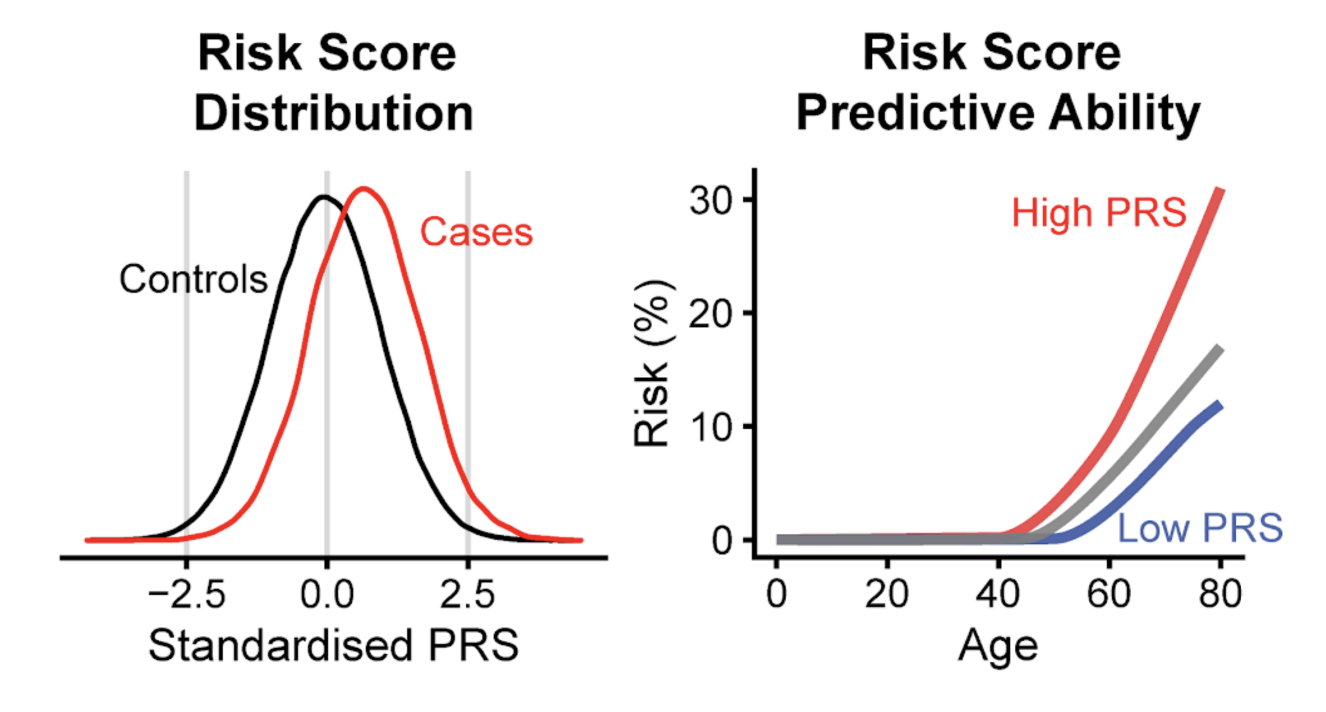

In [3]:
from IPython.display import Image, display
display(Image(filename="../docs/static/figures/PGS_Illustration.png", width=600))

**How do we compute PGSs?**

By now you are likely quite familiar with GWAS, and you know that it gives you, for each variant in the genome, an estimate effect size ($\beta$, the regression coefficient), describing how much each allele copy affects the phenotype.

| Variant | Effect allele | $\beta$ (effect size) | Individual's dosage |
|---------|---------------|------------------------|---------------------|
| SNP 1   | A             | $+0.15$                | 2                   |
| SNP 2   | T             | $-0.08$                | 1                   |
| SNP 3   | G             | $+0.22$                | 0                   |
| SNP 4   | C             | $+0.05$                | 2                   |
| SNP 5   | A             | $-0.12$                | 1                   |

Dosage here refers to the number of effect alleles an individual carries for a given variant. Now, if we have the actual genotypes for individuals, we can for example compute the score via a weighted sum of the dosages and the effect sizes:

In [4]:
import numpy as np
betas = np.array([0.15, -0.08, 0.22, 0.05, -0.12])
dosage = np.array([2, 1, 0, 2, 1])
print(f"PGS = {(betas * dosage).sum():.2f}")

PGS = 0.20


*In reality it's not quite this simple.* Real PGSs might use millions of variants, and complications include:

- **Linkage disequilibrium (LD)**: Nearby variants are correlated and might be tagging a single causal signal. Summing up all of them double counts that actual affect.
- **Noisy effect sizes:** Many GWAS $\beta$ estimates are small and noisy. Including them almost certainly hurts predictive performance, it's likely better to either need to downweight or drop them.

These, and other issues, have driven the development of a whole family of advanced and useful PGS methods, which differ in the way they handle the issues above:

- [Clumping + thresholding (C+T)](https://www.cell.com/ajhg/fulltext/S0002-9297(19)30422-7?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0002929719304227%3Fshowall%3Dtrue)
- [LDpred](https://www.cell.com/ajhg/fulltext/S0002-9297(15)00365-1?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0002929715003651%3Fshowall%3Dtrue) / [LDpred2](https://academic.oup.com/bioinformatics/article/36/22-23/5424/6039173?login=false)
- [PRS-CS](https://www.nature.com/articles/s41467-019-09718-5)

**Challenges with PGS**

While PGS have the potential to advance clinical decision making and help us understand biology, there are still numerous challenges that remain. Many of these have to do with the fact that most GWAS studies are performed in individuals of European ancestries, and as it turns out, these do not necessarily transfer/predict well into other ancestries.

***Question for you**: Let us imagine we perform a GWAS in a European centric population for a trait (e.g. HDL cholesterol), and we find that a PGS from this GWAS performs well at predicting the trait in a held-out test set from the same population. Now, let us imagine we use the same approach but now we apply it to a population more genetically distant from the population we derived the GWAS, and the performance drops significantly. Why might this be? What does this tell us about the $\beta$ values we derived in the GWAS? What would we expect if they were truly causal, and reflecting actual, human biological mechanisms?*

- **Ancestry transferability**:
    - *"[...] More than 85% of GWAS have been undertaken in individuals of European ancestries, and PRSs derived from these studies can be substantially less predictive for other genetic ancestries, potentially exacerbating health disparities."* (from [Principles and methods for transferring polygenic risk scores across global populations](https://www.nature.com/articles/s41576-023-00637-2)).
    - [Clinical use of current polygenic risk scores may exacerbate health disparities](https://www.nature.com/articles/s41588-019-0379-x)
- **Even within a specific ancestry, there can be many different types of confounding effects**
    - [Variable prediction accuracy of polygenic scores within an ancestry group](https://elifesciences.org/articles/48376)
    - [Fine-scale population structure and widespread conservation of genetic effect sizes between human groups across traits](https://www.nature.com/articles/s41588-024-02035-8)
- **There is a ceiling on what any given PGS can explain**
    - An additive PGS can not explain more than the trait's narrow sense heritability ($h^2 = \frac{V_A}{V_P}$ where $V_A$ is genetic variation due to additive effects and $V_P$ is the total phenotypic variation). This is a fundamental limit of the trait's genetic architecture, not something that bettter additive methods or more data can go beyond.
    - See [Pitfalls of predicting complex traits from SNPs](https://pubmed.ncbi.nlm.nih.gov/23774735/) and [Estimating Trait Heritability](https://www.nature.com/scitable/topicpage/estimating-trait-heritability-46889).
- **Clinical utility is an open question and a work in progress**
    - *"Polygenic risk scores performed poorly in population screening, individual risk prediction, and population risk stratification. Strong claims about the effect of polygenic risk scores on healthcare seem to be disproportionate to their performance."*
    - [Performance of polygenic risk scores in screening, prediction, and risk stratification: secondary analysis of data in the Polygenic Score Catalog](https://bmjmedicine.bmj.com/content/2/1/e000554)
 

**Additional resources**

- [Wikipedia article on polygenic scores](https://en.wikipedia.org/wiki/Polygenic_score)
- [Tutorial: a guide to performing polygenic risk score analyses](https://www.nature.com/articles/s41596-020-0353-1)
- [Polygenic risk scores: from research tools to clinical instruments ](https://link.springer.com/article/10.1186/s13073-020-00742-5)
- [The Polygenic Score Catalog as an open database for reproducibility and systematic evaluation](https://www.nature.com/articles/s41588-021-00783-5)

## 1.2 From PGS to foundation models

Classical PGS is generally one trait at a time. One would run (or download) a GWAS for HDL cholesterol, derive a scoring method from the summary statistics, apply it to individuals. If one also wants a score for LDL, one would repeat the process for a LDL-specific GWAS results.

A foundation-style model takes a slightly different approach. Rather than building one model per trait, we train a single neural network on individual-level genotype-phenotype data for multiple traits at once, so the model learns a shared representation of the genome that can be used for multiple traits simultaneously. Once trained, we can apply the trained model to a new cohort (i.e., the genotypes in the new cohorts are inputs to the trained model), and for every individual in that new cohort, we get predictions for hundreds or thousands of traits at the same time.

**What this can, and cannot do**

- **PGS-style use**: For any given single trait the model was trained on, we can use its output directly as a polygenic score, and evaluate it (given we have the true labels in our new cohort/dataset). We will see some examples of this later in the notebook for e.g. HDL and CAD.
- **Phenome-wide prediction**: The same prediction command/workflow produces predictions for every trait the model was trained on. Instead of devoting time to gather and process individual GWAS results across hundreds of traits, there is essentially additional zero development cost whether researchers are interested in a single trait or multiple.
- **Multi-trait profiling of individuals**: Having predictions for multiple traits enables different types of questions compared to a single trait. For example, instead of *what's this person's risk for disease X?*, we can explore questions like *what does this person's entire genetic profile look like across hundreds of traits?*. Useful for clustering individual, identifying outliers across multiple traits, etc.]
- **(Potentially) non-additive effects**: Neural networks can in theory capture genetic effects beyond the additive narrow sense heritability such as dominance and epistasis that additive PGS methods cannot capture directly. Whether this translates into concrete accuracy gains for complex traits is debated ([1](https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1000008), [2](https://pubmed.ncbi.nlm.nih.gov/25683123/)) - but research is ongoing ([3](https://academic.oup.com/nar/article/51/12/e67/7177885), [4](https://www.biorxiv.org/content/10.1101/2025.10.26.684578v1)).

Overall, we view these types of foundation models as *complementary tools* to the already established PGS in the genetic prediction toolbox. For maximizing accuracy on an additive complex trait where well powered GWAS exist, well-tuned methods like LDpred2 or PRS-CS often match or exceed multi-task foundation model performance on the given trait. One value of the foundation style model the capability to capture and predict hundreds of traits in one go, and in practice one might use both. For example ensemble predictions (where one averages predictions from both classical and foundation models) generally perform better than either alone, indicating that the two methods are capturing different signals. 

## 1.3 What you will do here

For the rest of this noteboo, we will go through using a pretrained EIR-FM model end-to-end to predict around ~300 phenotypes on a real external cohort. We will not be training the model here, that has already been done and would require a large individual level dataset (such as the UK Biobank) and a GPU accelerator. This model has already been trained on the UK Biobank, we will download this model, apply it to a new dataset (PennCATH) and explore the predictions.

Specifically, we will:

- **Run inference with the pre-trained foundation model**: This uses the PennCATH genotype data as input, and using the `eirpredict` command will produce the ~300 trait predictions per individual.
- **Load and merge** the *real* measured included in the PennCATH cohort. This we can use as a ground truth to evaluate the predictions in various ways.
- **Evaluate continuous predictions**: HDL, LDL and triglycerides were measured in the PennCATH cohort, we can e.g. examine how these correlate with the matching predicted phenotypes, same as one would generally do in a PGS/PRS study.\
- **Quantify how much the predicted phenotypes add beyond baseline covariates**: By comparing a baseline regression model (e.g. age and sex only) with one that includes the predicted phenotype, we can compute something called *incremental $R^2$* that allows us to examine how much predicted values actually add beyond basic covariates.
- **Evaluate binary disease prediction** for coronary artery disease (CAD), using a similar approach as we did with the lipid phenotypes, but this time exploring a binary (classification) target, and how we can use ROC-AUC and precision-recall curves, applying the same incremental approach as for the continuous phenotypes.
- **Explore all the predicted phenotypes**: We can explore the "phenome" generally, to see how traits that were not even measured in PennCATH relate to each other, we can do clustering and visualize how individuals relate to each other via PCA and UMAP.

**Dataset**

We will use the PennCATH cohort. The cohort is described [here](https://pmc.ncbi.nlm.nih.gov/articles/PMC3297116/), and the version we use contains 1,401 individuals on the GRCh38 (hg38) build, with measured phenotypes for CAD status, age, sex, triglycerides, HDL cholesterol and LDL cholesterol. Note that since this is a relatively small cohort by today's standards, it is very unlikely one could get a powerful enough GWAS or trained a model from scratch on this data. However, we can take the information learned in the UKB (n=~500K) and transfer that into this cohort to allow for some interesting analysis.

# 2. Data setup

In [1]:
# !uv pip install gdown
# !uv pip install umap-learn

import gdown

In [ ]:
model_zip_id = "1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W"
output = "../reference_data/models/"
gdown.download(id=model_zip_id, output=output)

In [3]:
penncath_hg38_id = "1d1phne1USPa7gkj7LOneyFH9zcGexvHs"
output = "../reference_data/"
gdown.download(id=penncath_hg38_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs
From (redirected): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs&confirm=t&uuid=479fc4c7-1272-4930-9227-427ea89da96d
To: /Users/txb777/Projects/phd/integrative_post_gwas_methods_course/reference_data/penncat_hg38.zip
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143M/143M [00:01<00:00, 73.9MB/s]


'../reference_data/penncat_hg38.zip'

In [4]:
!unzip -o ../reference_data/penncat_hg38.zip -d ../reference_data

Archive:  ../reference_data/penncat_hg38.zip
  inflating: ../reference_data//penncath_hg38/penncath.csv  
  inflating: ../reference_data//penncath_hg38/penncath.bim  
  inflating: ../reference_data//penncath_hg38/penncath.bed  
  inflating: ../reference_data//penncath_hg38/penncath.fam  


# 3. Prediction

Notice above how we downloaded this perhaps weirdly named `ext_d_inf_moe_general_16L-FUS_multitask.zip` file? These are trained neural network weights, where the model was trained on the UK Biobank to predict hundreds of traits from genotype data (e.g. anthropometrics, diseases, lipids, etc.). After downloading this file, and preparing our individual level genotype data, we can pass both of them to the `eirpredict` command that predicts into the PennCATH dataset.

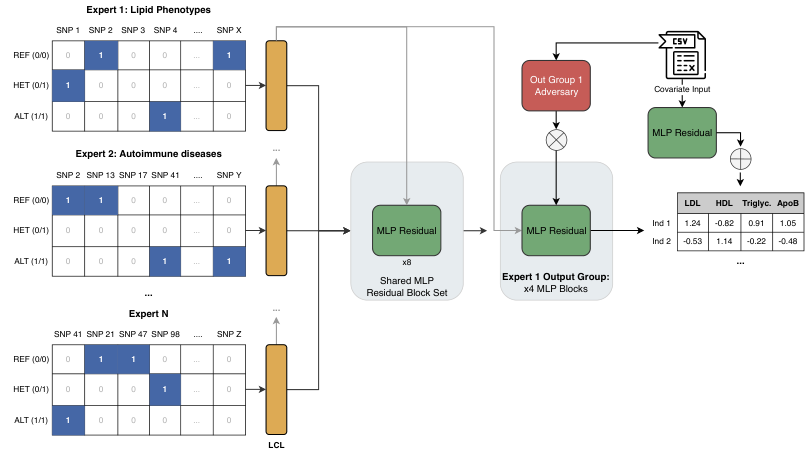

In [7]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/eir_fm_architecture.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

**Note**: The command just prints might take a couple of seconds before it starts to print anything on the screen as the necessary deep-learning software libraries are loaded. 

In [5]:
!eirautogppredict --genotype_data_path ../reference_data/penncath_hg38 --packed_experiment_path ../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip --output_folder ../output

09:44:48 - WARNING - eir_auto_gp.predict.prepare_data - Dropping 1 ambiguous (palindromic) SNPs.
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Matching Stats: Exact=31513, Reversal=15743, StrandFlip=31404, Flip+Rev=15868
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Applying PLINK pre-filtering (94528/861221 SNPs matched)
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Created extract list with 94528 unique VAR_IDs from 94528 matched SNPs
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Running: plink2 --bfile ../reference_data/penncath_hg38/penncath --extract ../output/data/plink_temp_ba527966/extract_list.txt --make-bed --keep-allele-order --out ../output/data/plink_temp_ba527966/filtered
09:44:49 - INFO - eir_auto_gp.predict.prepare_data - PLINK filtering completed successfully
09:44:49 - INFO - eir_auto_gp.predict.prepare_data - PLINK stdout: PLINK v2.0.0-a.6.4 M1 (6 Dec 2024)                 cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christophe

# 4. Analysis

!TODO: What we are doing in the analysis section.

## 4.1 Imports and setup

In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

In [6]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

## 4.2 Loading in the predictions

When we use the `eirpredict` command, the model generates prediction for each individual, for each target phenotype the model was originally trained for. Each predicted phenotype results in a single `.csv` file saved on the disk. The `... Ensemble` column is the average of training multiple folds (i.e. slightly different versions of the model, which allows estimating uncertainty in any given prediction among other things), since we only have a single fold in this case, the `... Ensemble` column is the same as the `Fold 0` column.

In [7]:
!ls "../output/results" | head

Alanine_aminotransferase.csv
Albumin_BIOCH.csv
Alkaline_phosphatase.csv
Apolipoprotein_A.csv
Apolipoprotein_A1.csv
Apolipoprotein_B_BIOCH.csv
Apolipoprotein_B_METAB.csv
Aspartate_aminotransferase.csv
Average_Diameter_for_HDL_Particles.csv
Average_Diameter_for_VLDL_Particles.csv


In [8]:
!head "../output/results/Alanine_aminotransferase.csv"

ID,Alanine_aminotransferase Fold 0,Alanine_aminotransferase Ensemble
10002,22.542772,22.542772
10004,28.100965,28.100965
10005,22.484835,22.484835
10007,23.97966,23.97966
10008,26.343996,26.343996
10009,26.6976,26.6976
10010,21.769466,21.769466
10011,22.51627,22.51627
10012,22.866842,22.866842


The code below essentially gathers upp all these `.csv` files for all the predicted phenotypes into a single data frame, so for each of the 1401 individuals in the PennCATH dataset, we end up with 315 (237 continuous and 78 binary) "features" (i.e., predicted phenotypes).

In [9]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

preds = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {preds.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
display(preds.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542772,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.537926,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361750,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.547020,76.31497,6.289234,52.096508,23.333853,37.992416
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930590,76.097400,75.78765,6.923183,51.953293,26.081810,37.976200
10007,23.979660,45.518280,87.363420,1.639348,1.566334,1.016251,0.852204,24.755083,9.717244,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.782000,70.52157,6.385489,49.508488,22.894983,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.507370,78.36777,6.650043,52.501266,23.214048,38.252075


## 4.3 Loading the actual, measured PennCATH labels

Here we load in the *actual* measured phenotypes in the PennCATH, which we will compare and analyze with the predicted values from the UKB trained model.

In [10]:
labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {labels.shape}")
display(labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## 4.4 Merging true PennCATH labels with relevant predictions

Notice above the real, measured phenotypes in PennCATH include Triglycerides (`tg`), HDL Cholesterol (`hdl`) and LDL Cholesterol (`ldl`). Lucily, we have the same phenotypes (albeit named slightly differently) in the model trained in the UKB, which allows us to directly compare the predictions for these 3 phenotypes to the real values. 

In [11]:
continuous_traits = {
    'TG': 'Triglycerides',
    'HDL': 'HDL Cholesterol',
    'LDL': 'LDL Cholesterol'
}

binary_traits = {
    'CAD': 'Coronary Artery Disease'
}

In [12]:
rename_preds = {
    'I25': 'CAD_pred',
    'Total_Triglycerides': 'TG_pred',
    'HDL_cholesterol': 'HDL_pred',
    'LDL_Cholesterol': 'LDL_pred'
}

rename_true = {
    'CAD': 'CAD_true',
    'tg': 'TG_true',
    'hdl': 'HDL_true',
    'ldl': 'LDL_true'
}

preds_copy = preds.reset_index()
preds_copy = preds_copy[['ID'] + list(rename_preds.keys())].copy()
preds_renamed = preds_copy.rename(columns=rename_preds)
true_renamed = labels.rename(columns=rename_true)

df_real_final = pd.merge(preds_renamed, true_renamed, on='ID', how='inner')
print(f"merged: {df_real_final.shape}")
display(df_real_final.head())

merged: (1401, 11)


,ID,CAD_pred,TG_pred,HDL_pred,LDL_pred,CAD_true,sex,age,TG_true,HDL_true,LDL_true
0,10002,0.299964,1.445587,1.431592,1.888146,1,1,60,NaN,NaN,NaN
1,10004,0.366859,1.230927,1.444633,1.623983,1,2,50,55.0,23.0,75.0
2,10005,0.418133,1.732881,1.349207,1.733176,1,1,55,105.0,37.0,69.0
3,10007,0.428991,1.272115,1.598767,1.763022,1,1,52,314.0,54.0,108.0
4,10008,0.453609,1.419624,1.304491,1.781938,1,1,58,161.0,40.0,94.0


## 4.5 Evaluation of Continuous Traits

So, as mentioned above, for the first analysis, we will compare how some of the predicted phenotypes from the UKB model above match 

!TODO: Indicate why we need the Z-score here (i.e. Unit conversion (Converted): mmol/L → mg/dL).

In [13]:
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

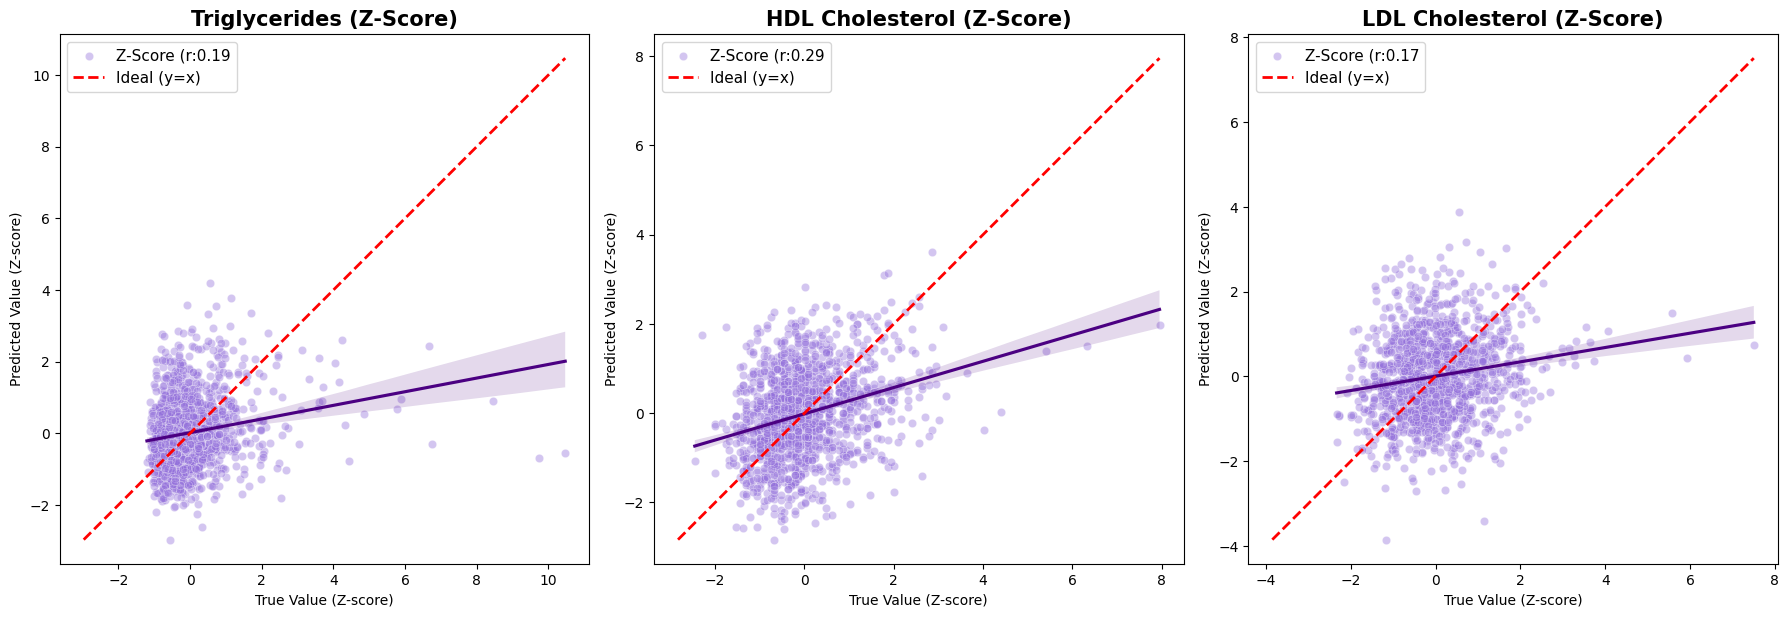

In [14]:
df_zscore = df_real_final.copy()
scaler = StandardScaler()

for trait in continuous_traits.keys():
    df_zscore[f'{trait}_true_z'] = scaler.fit_transform(df_zscore[[f'{trait}_true']])
    df_zscore[f'{trait}_pred_z'] = scaler.fit_transform(df_zscore[[f'{trait}_pred']])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, trait in enumerate(continuous_traits.keys()):
    cols = [f'{trait}_true_z', f'{trait}_pred_z']
    valid_data = df_zscore[cols].dropna()
    
    y_true_z = valid_data[f'{trait}_true_z']
    y_pred_z = valid_data[f'{trait}_pred_z']
    
    ax = axes[i]
    
    corr_z, _ = pearsonr(y_true_z, y_pred_z)
    
    label_z = f'Z-Score (r:{corr_z:.2f}'
    
    sns.scatterplot(x=y_true_z, y=y_pred_z, alpha=0.4, ax=ax, label=label_z, color='mediumpurple')
    sns.regplot(x=y_true_z, y=y_pred_z, scatter=False, ax=ax, color='indigo', )
 
    all_vals = pd.concat([y_true_z, y_pred_z])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    
    ax.set_title(f'{continuous_traits[trait]} (Z-Score)', fontsize=15, fontweight='bold')
    ax.set_xlabel('True Value (Z-score)')
    ax.set_ylabel('Predicted Value (Z-score)')
    
    ax.legend(loc='upper left', fontsize=11)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## Checking for counfounding - how much do predictions improve over a baseline?

As you might know, GWAS (and by extension PGS and PRS) can be famously tricky due to confounders like ancestry bias or population stratification. If our model has e.g. learned a proxy for demographic variables in the UKB genetic data, and this bias is also reflected in PennCATH then it might seem like the model is effective at predicting Triglycerides from genetic data when when in reality, it is mostly just capturing the baseline differences in Triglycerides between males and females.

One way to check for this is to example how much the phenotype predictions *improve* over a baseline where we account for variables that 

**References:**

- [Apparent latent structure within the UK Biobank sample has implications for epidemiological analysis](https://www.nature.com/articles/s41467-018-08219-1) (discusses the importance of correcting for confounding, and how even the current approaches might not always be sufficient)
- [Tutorial: a guide to performing polygenic risk score analyses](https://www.nature.com/articles/s41596-020-0353-1) (besides being a great resource, discusses incremental R2)

!TODO: Add more citations/links to confounding examples

In [15]:
import statsmodels.formula.api as smf

df = df_real_final.copy()

for trait, full_name in continuous_traits.items():
    y_col = f"{trait}_true"
    prs_col = f"{trait}_pred"
    
    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    model_base = smf.ols(formula=formula_base, data=df).fit()
    r2_base = model_base.rsquared * 100
    
    # Full Model
    formula_full = f"{y_col} ~ age + sex + {prs_col}"
    model_full = smf.ols(formula=formula_full, data=df).fit()
    r2_full = model_full.rsquared * 100
    
    # Delta R2
    delta_r2 = r2_full - r2_base
    
    # P-value for the PRS term in the full model
    p_val_prs = model_full.pvalues[prs_col]
    
    print(f"[{trait} - {full_name}]")
    print(f" - Base R2 (age, sex): {r2_base:.2f}%")
    print(f" - Full R2 (+ PRS)  : {r2_full:.2f}%")
    print(f" - Delta R2         : +{delta_r2:.2f}% (p-value: {p_val_prs:.2e})\n")

[TG - Triglycerides]
 - Base R2 (age, sex): 2.91%
 - Full R2 (+ PRS)  : 5.74%
 - Delta R2         : +2.84% (p-value: 5.02e-10)

[HDL - HDL Cholesterol]
 - Base R2 (age, sex): 15.60%
 - Full R2 (+ PRS)  : 22.24%
 - Delta R2         : +6.64% (p-value: 4.75e-25)

[LDL - LDL Cholesterol]
 - Base R2 (age, sex): 1.80%
 - Full R2 (+ PRS)  : 4.70%
 - Delta R2         : +2.89% (p-value: 6.39e-10)



## Evaluation of Binary Traits

Given that our model can somewhat predict the lipid phenotypes above, and it does seem to meaningfully improve over the age and sex covariate baselines, we can explore how well it predicts Coronary Artery Disease in PennCATH. For this, we use the I25 (which is the ICD10 code for [Chronic ischaemic heart disease](https://icd.who.int/browse10/2019/en#/I25)) disease prediction from the DL model. 

In typical ML scenarios, we often use metrics such as accuracy, F1 score etc to evaluate our models. However, in genetic prediction settings, we rarely use a hard classification threshold which is used in metrics such as accuracy (e.g. >50% prediction confidence a sample is "assigned" the positive label). Because overall prevalence for a disease like CAD might be extremely low in the cohort, setting a rigid cut-off might simply assign all individuals being "negative" - not very useful despite giving a "high accuracy" in a imbalanced dataset. Additionally, for most disease traits, genetic predisposition acts more on a continuous spectrum (i.e., it is not that having a given allele makes it certain that you get a given disease)

!TODO: Link to ROC-AUC and PR-AUC

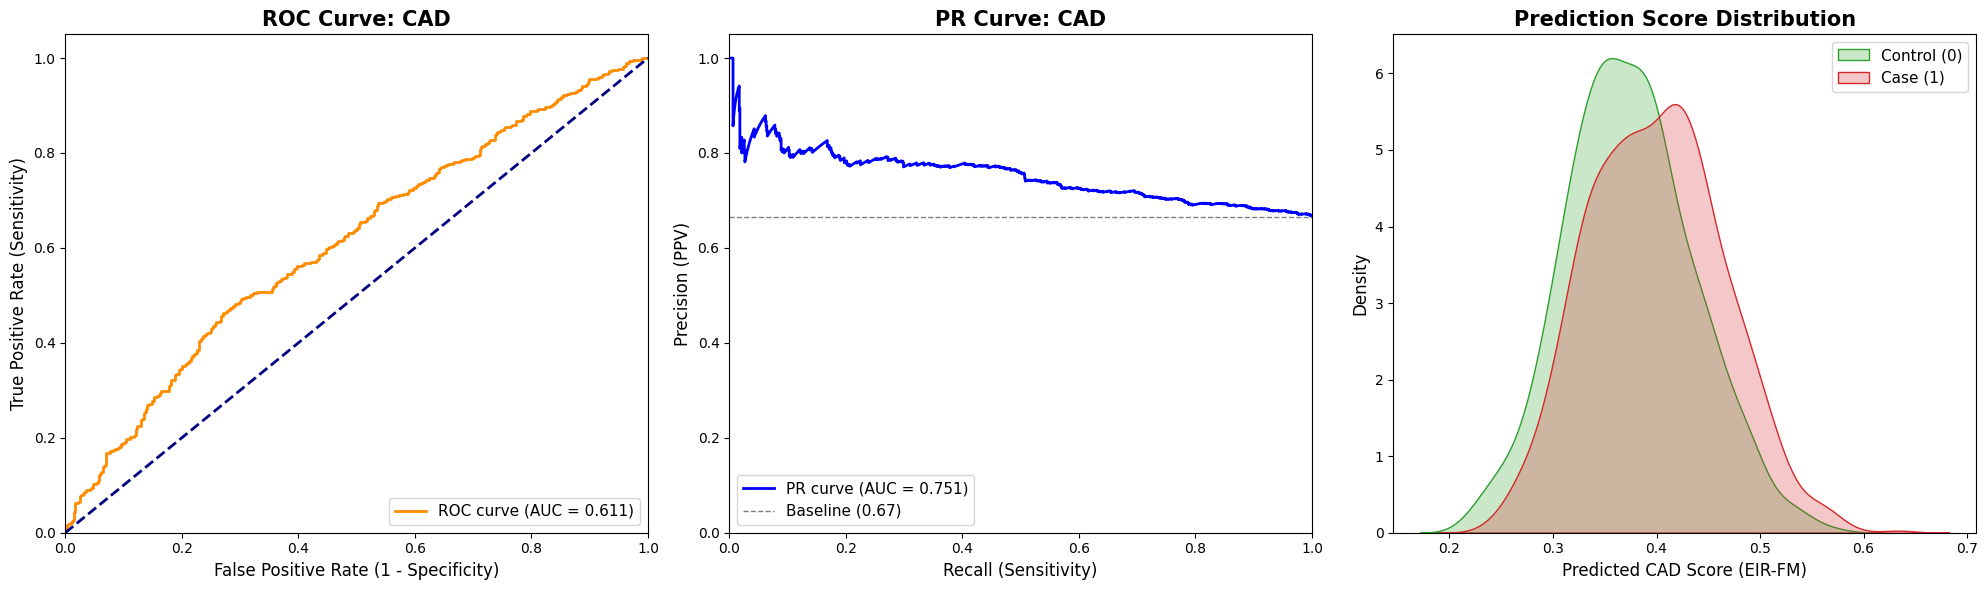

In [16]:
for trait, full_name in binary_traits.items():
    true_col = f'{trait}_true'
    pred_col = f'{trait}_pred'
    
    valid_data = df[[true_col, pred_col]].dropna()
    y_true = valid_data[true_col]
    y_score = valid_data[pred_col]
    
    roc_auc = roc_auc_score(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[0].set_title(f'ROC Curve: {trait}', fontsize=15, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=11)

    axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    baseline = y_true.sum() / len(y_true)
    axes[1].axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
    axes[1].set_ylabel('Precision (PPV)', fontsize=12)
    axes[1].set_title(f'PR Curve: {trait}', fontsize=15, fontweight='bold')
    axes[1].legend(loc="lower left", fontsize=11)

    sns.kdeplot(data=valid_data[valid_data[true_col] == 0][pred_col], 
                ax=axes[2], fill=True, color='#2ca02c', label='Control (0)')
    sns.kdeplot(data=valid_data[valid_data[true_col] == 1][pred_col], 
                ax=axes[2], fill=True, color='#d62728', label='Case (1)')
    axes[2].set_title(f'Prediction Score Distribution', fontsize=15, fontweight='bold')
    axes[2].set_xlabel(f'Predicted {trait} Score (EIR-FM)', fontsize=12)
    axes[2].set_ylabel('Density', fontsize=12)
    axes[2].legend(loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.show()

In [17]:
for trait, full_name in binary_traits.items():
    y_col = f"{trait}_true"
    pred_col = f"{trait}_pred"

    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    logit_base = smf.logit(formula=formula_base, data=df).fit(disp=0)
    
    auc_base = roc_auc_score(df[y_col], logit_base.predict(df))
    pseudo_r2_base = logit_base.prsquared * 100

    # Full Model
    formula_full = f"{y_col} ~ age + sex + {pred_col}"
    logit_full = smf.logit(formula=formula_full, data=df).fit(disp=0)
    
    auc_full = roc_auc_score(df[y_col], logit_full.predict(df))
    pseudo_r2_full = logit_full.prsquared * 100

    delta_auc = auc_full - auc_base
    delta_pseudo_r2 = pseudo_r2_full - pseudo_r2_base
    
    p_val_score = logit_full.pvalues[pred_col]

    print(f"[{trait} - {full_name}]")
    print(f" - Base Model (age, sex)")
    print(f"   * AUC: {auc_base:.4f} | Pseudo-R²: {pseudo_r2_base:.2f}%")
    
    print(f" - Full Model (+ {trait} Score)")
    print(f"   * AUC: {auc_full:.4f} | Pseudo-R²: {pseudo_r2_full:.2f}%")
    
    print(f" - Incremental Gain (Delta)")
    print(f"   * Delta AUC: +{delta_auc:.4f}")
    print(f"   * Delta R² : +{delta_pseudo_r2:.2f}% (p-value: {p_val_score:.2e})\n")

[CAD - Coronary Artery Disease]
 - Base Model (age, sex)
   * AUC: 0.7778 | Pseudo-R²: 20.51%
 - Full Model (+ CAD Score)
   * AUC: 0.7881 | Pseudo-R²: 21.96%
 - Incremental Gain (Delta)
   * Delta AUC: +0.0102
   * Delta R² : +1.45% (p-value: 5.84e-07)



## Clustering correlated traits

So far we have only evaluated traits where we also have ground-truth measurements in PennCATH (the lipid panel and CAD). However, the model also gives us predictions for ~230 other continuous traits per individual — for the vast majority of which we do *not* have measured values to compare against. We can still learn something useful from these predictions by looking at how they relate to *each other*.

Many of these predicted phenotypes are biologically related (e.g. the lipid panel, blood cell counts, kidney markers, liver enzymes, anthropometrics), so we would expect their predictions to be correlated. Examining this correlation structure is useful for several reasons:

- **Sanity check** — biologically related traits should cluster together if the model has learned meaningful biology rather than spurious signal.
- **Identifying redundancy** — if two predicted traits are nearly perfectly correlated, one of them carries little additional information and the pair likely reflects the same underlying biological measurement.
- **Surfacing unexpected structure** — unrelated traits clustering together might point to a shared confounder (e.g. ancestry, age, sex) being captured by the model, rather than independent biological signal.

Below we compute **Spearman correlation** (rank-based, robust to non-linear monotonic relationships and to outliers) across all predicted continuous traits, and then **hierarchically cluster** the resulting matrix so that related traits end up adjacent in the heatmap. Blocks of red (positive correlation) or blue (negative correlation) along the diagonal correspond to groups of traits the model treats similarly.

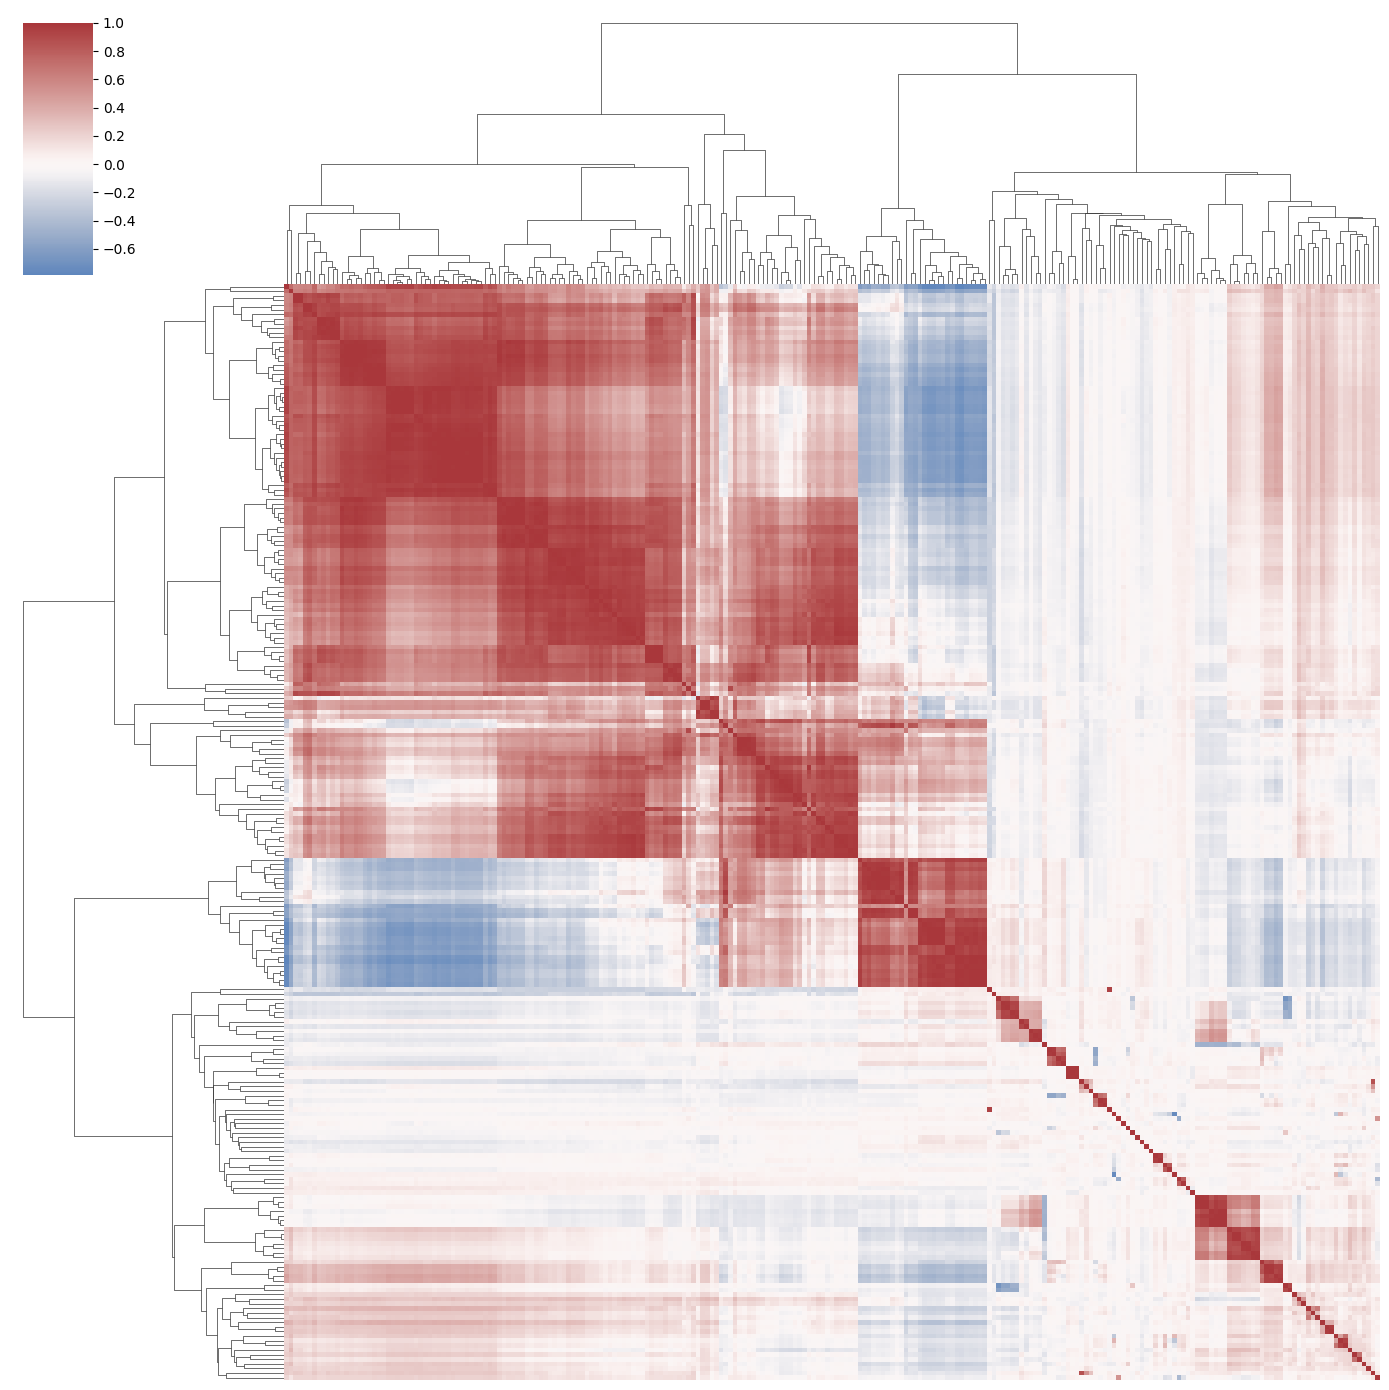

Continuous traits in correlation: 237


In [18]:
df = preds.copy()

cont_traits = trait_kind.index[trait_kind == "continuous"].tolist()
cont = df[cont_traits].apply(pd.to_numeric, errors="coerce")
cont = cont.loc[:, cont.std() > 0]
corr = cont.corr(method="spearman")

order = sns.clustermap(corr, cmap="vlag", center=0, figsize=(14, 14),
                    xticklabels=False, yticklabels=False).dendrogram_row.reordered_ind
plt.show()
print(f"Continuous traits in correlation: {corr.shape[0]}")

In [23]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs.sort_values("spearman", ascending=False).head(10)

,trait_a,trait_b,spearman
27951,Weight_ANTHRO,Weight_IMPED,0.997179
4328,Cholesterol_in_Large_HDL,Cholesteryl_Esters_in_Large_HDL,0.996765
13564,Concentration_of_Very_Small_VLDL_Particles,Total_Lipids_in_Very_Small_VLDL,0.996750
24926,Phospholipids_in_Very_Small_VLDL,Total_Lipids_in_Very_Small_VLDL,0.996470
2766,Body_mass_index_BMI_ANTHRO,Body_mass_index_BMI_IMPED,0.996365
12874,Concentration_of_Small_VLDL_Particles,Total_Lipids_in_Small_VLDL,0.996149
6246,Cholesterol_in_Very_Large_HDL,Cholesteryl_Esters_in_Very_Large_HDL,0.996089
4753,Cholesterol_in_Large_VLDL,Cholesterol_in_Very_Large_VLDL,0.995785
23911,Phospholipids_in_Large_HDL,Total_Lipids_in_Large_HDL,0.995528
24767,Phospholipids_in_Very_Large_HDL,Total_Lipids_in_Very_Large_HDL,0.995453


In [22]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs.sort_values("spearman", ascending=False).tail(10)

,trait_a,trait_b,spearman,abs_r
2167,Average_Diameter_for_VLDL_Particles,Free_Cholesterol_in_Large_HDL,-0.746912,0.746912
2265,Average_Diameter_for_VLDL_Particles,Total_Lipids_in_Large_HDL,-0.751532,0.751532
2276,Average_Diameter_for_VLDL_Particles,Total_Lipids_in_Very_Large_HDL,-0.752702,0.752702
1860,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,-0.755922,0.755922
2234,Average_Diameter_for_VLDL_Particles,Phospholipids_in_Very_Large_HDL,-0.761117,0.761117
2177,Average_Diameter_for_VLDL_Particles,Free_Cholesterol_in_Very_Large_HDL,-0.764903,0.764903
2123,Average_Diameter_for_VLDL_Particles,Cholesteryl_Esters_in_Very_Large_HDL,-0.770652,0.770652
2106,Average_Diameter_for_VLDL_Particles,Cholesterol_in_Very_Large_HDL,-0.774212,0.774212
2097,Average_Diameter_for_VLDL_Particles,Cholesterol_in_Large_HDL,-0.777138,0.777138
2113,Average_Diameter_for_VLDL_Particles,Cholesteryl_Esters_in_Large_HDL,-0.784499,0.784499


We can also check the top 5 positive and negatively correlated phenotypes for a given phenotype.

In [37]:
target = "Lipoprotein_a"
pd.DataFrame(pd.concat([corr[target].sort_values(ascending=False).head(5), corr[target].sort_values(ascending=False).tail(5)]))

KeyError: 'Lipoprotein_a'

The table above lists the 20 most strongly correlated trait *prediction* pairs (by absolute Spearman correlation). A few patterns stand out:

- **Same biological measurement, different assays** — e.g. `Weight_ANTHRO` vs `Weight_IMPED` (anthropometric vs impedance-based weight) and `Body_mass_index_BMI_ANTHRO` vs `Body_mass_index_BMI_IMPED`. These should be near-perfectly correlated, which is a good sanity check.
- **Lipoprotein sub-fraction redundancy** — most of the remaining top pairs are different lipid components of the *same particle* (e.g. Cholesterol, Cholesteryl Esters, Free Cholesterol, Phospholipids within Large HDL or Very Small VLDL). Total lipid content of a particle class is essentially a sum of its parts, so the model output reflects that.

## Cluster visualization

The correlation analysis above looked at relationships between *traits*. Here we flip the perspective and look at the relationships between *individuals*. Each individual is now represented as a vector of ~230 trait predictions, and we would like to know whether individuals form meaningful groups (e.g. by ancestry, sex, age, disease subtype) in this prediction space.

Since we cannot directly plot a 230-dimensional space, we use two complementary dimensionality reduction techniques to project each individual onto 4 components, then visualize all pairwise combinations of those components:

- **PCA (Principal Component Analysis)** — a *linear* method that finds orthogonal axes capturing maximum variance. The leading PCs often correspond to broad biological gradients (ancestry, sex, age) when applied to phenotypic data, and are useful as a first pass. The percentage on each axis label is the fraction of total variance explained by that component.
- **UMAP (Uniform Manifold Approximation and Projection)** — a *non-linear* method that preserves local neighborhood structure better than PCA, often revealing discrete clusters that get blurred together when projected linearly.

If PCA shows a smooth continuous gradient while UMAP shows discrete clumps, the two are giving you complementary views of the same underlying structure: PCA tells you about dominant axes of variation, UMAP tells you about local groupings.

> **Note**: To make the clustering more interpretable, you would typically color the points by a known covariate (sex, age decile, ancestry, case/control status). The plots below are unlabelled — try re-coloring them yourself using `labels` to see whether the structure aligns with anything you can name.

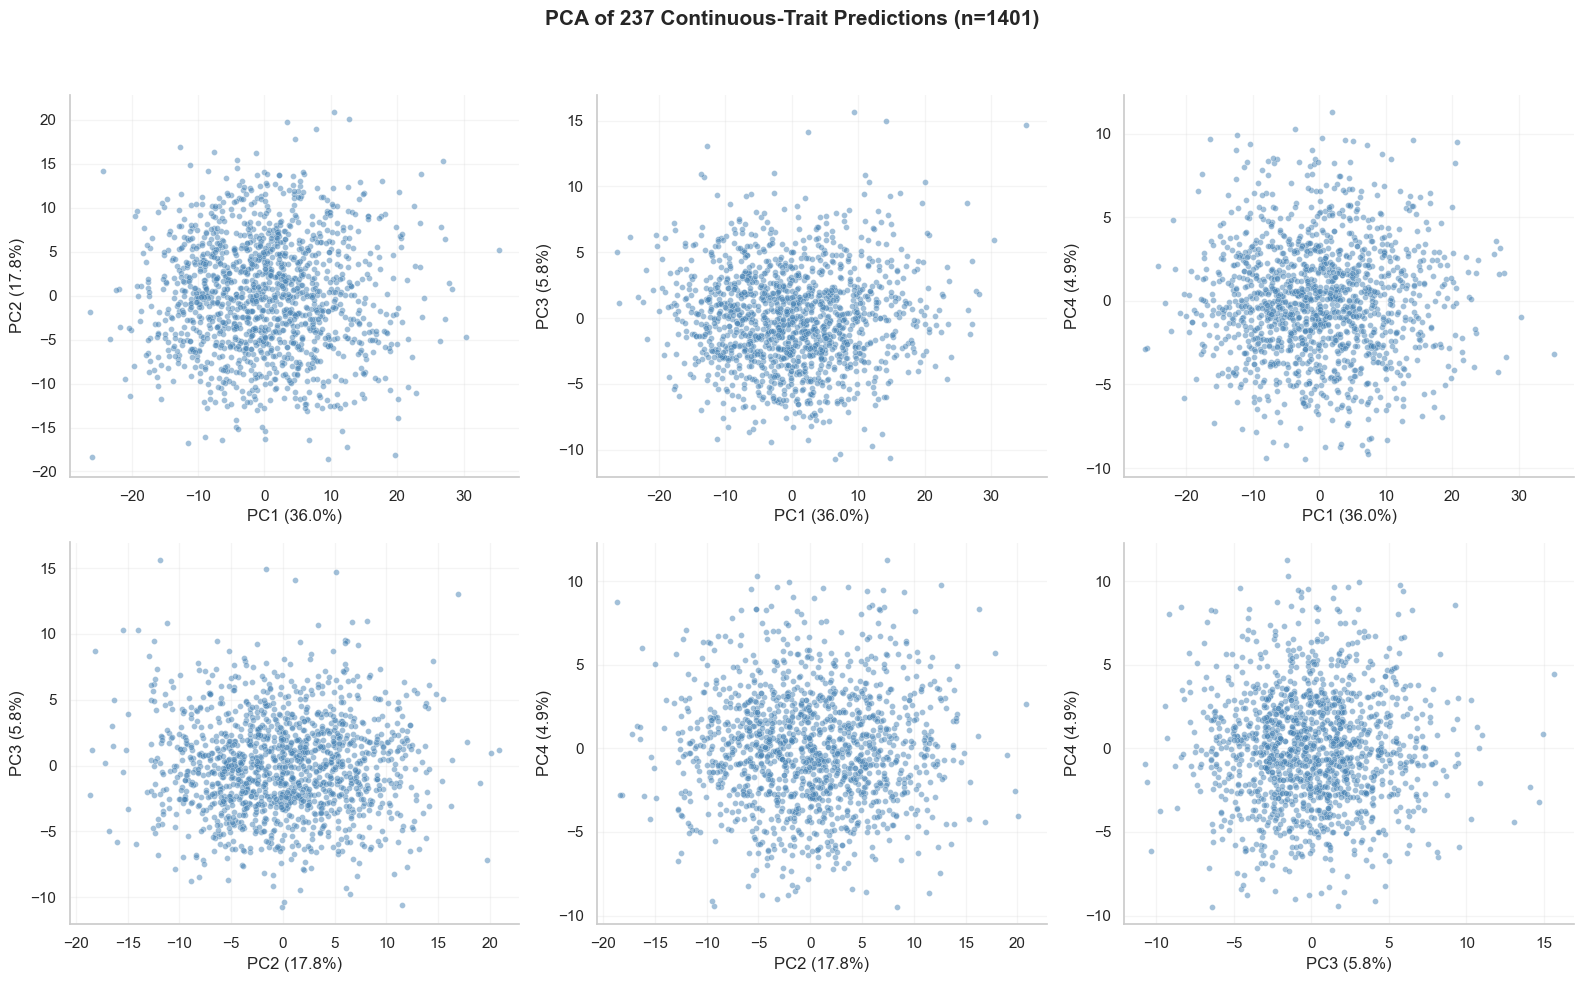

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations

X_df = df[cont.columns].dropna(axis=1, thresh=int(0.95 * len(df)))
X = StandardScaler().fit_transform(X_df.values)

pca = PCA(n_components=4, random_state=0)
pcs = pca.fit_transform(X)
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(pc_df[f"PC{i}"], pc_df[f"PC{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", color='steelblue') 
    
    var_i = pca.explained_variance_ratio_[i-1]
    var_j = pca.explained_variance_ratio_[j-1]
    
    ax.set_xlabel(f"PC{i} ({var_i*100:.1f}%)")
    ax.set_ylabel(f"PC{j} ({var_j*100:.1f}%)")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"PCA of {X_df.shape[1]} Continuous-Trait Predictions (n={len(pc_df)})", 
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*For reference: PCA of the same model's predictions on the **Human Origins** dataset, which spans many continental backgrounds. If ancestry were heavily driving the predictions, we would expect populations to separate along the leading PCs. Instead the colors stay tangled across every PC pair.*

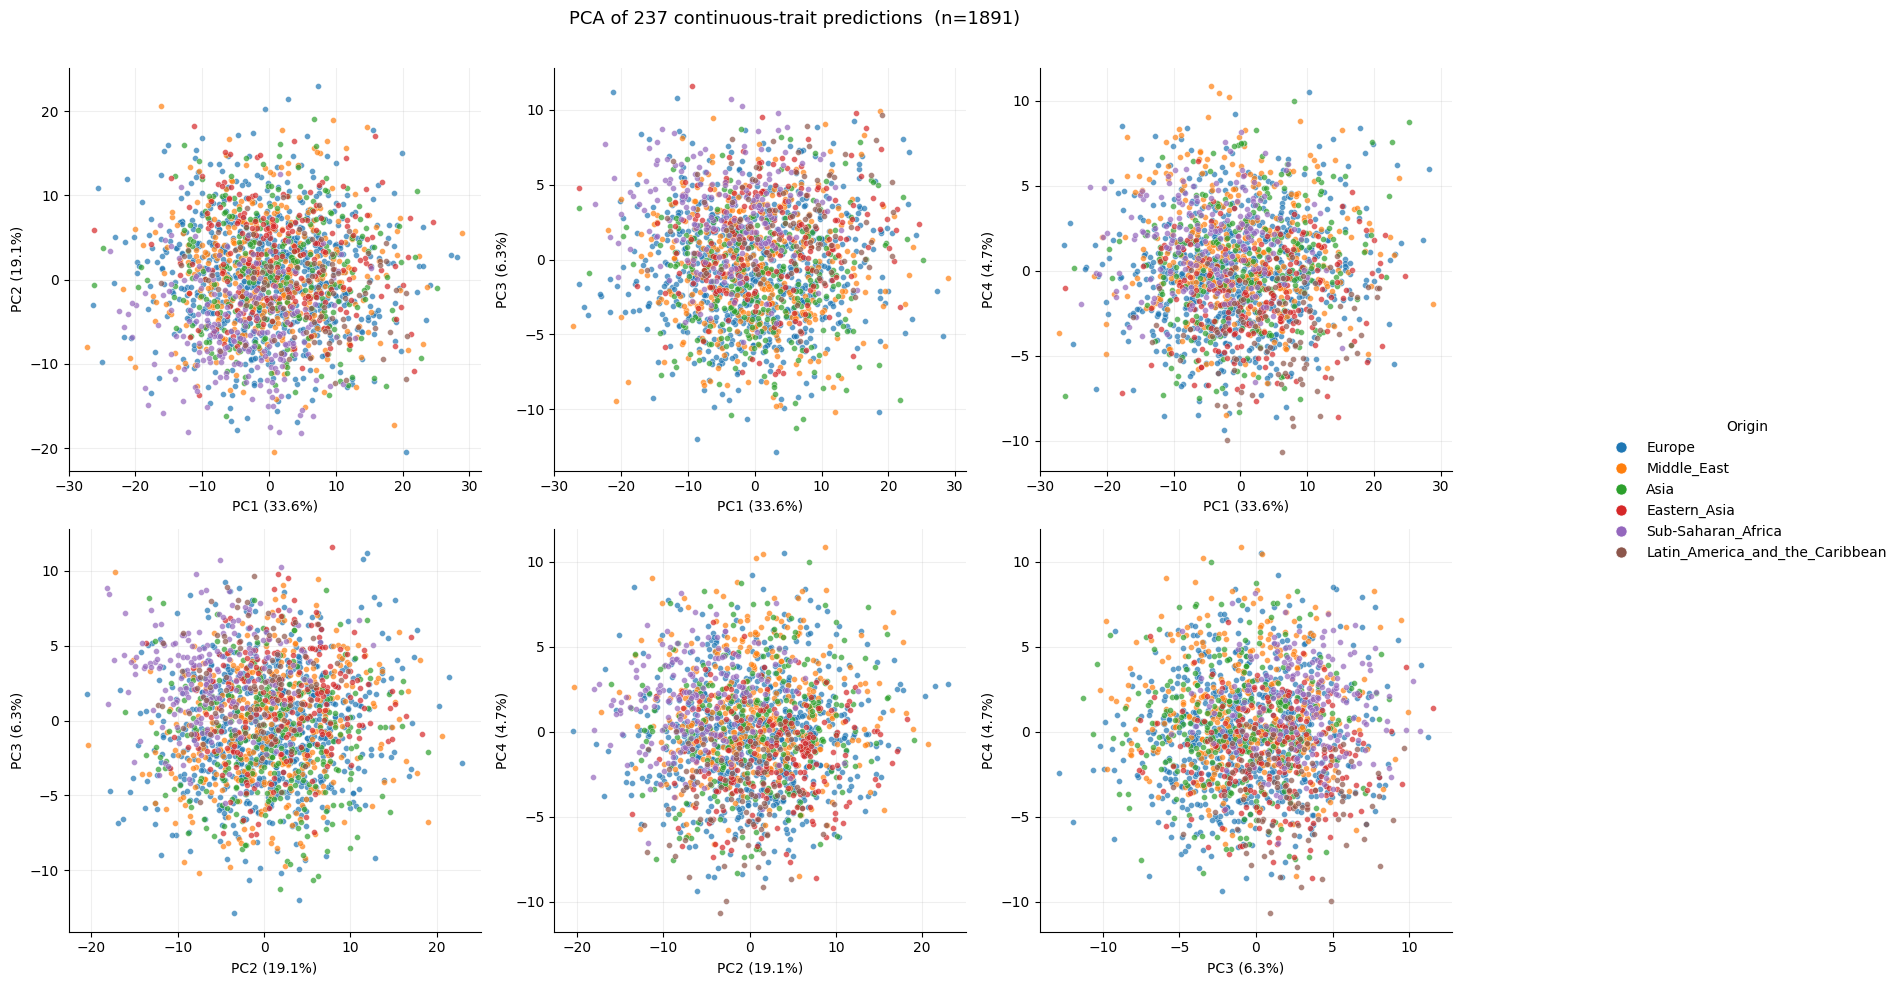

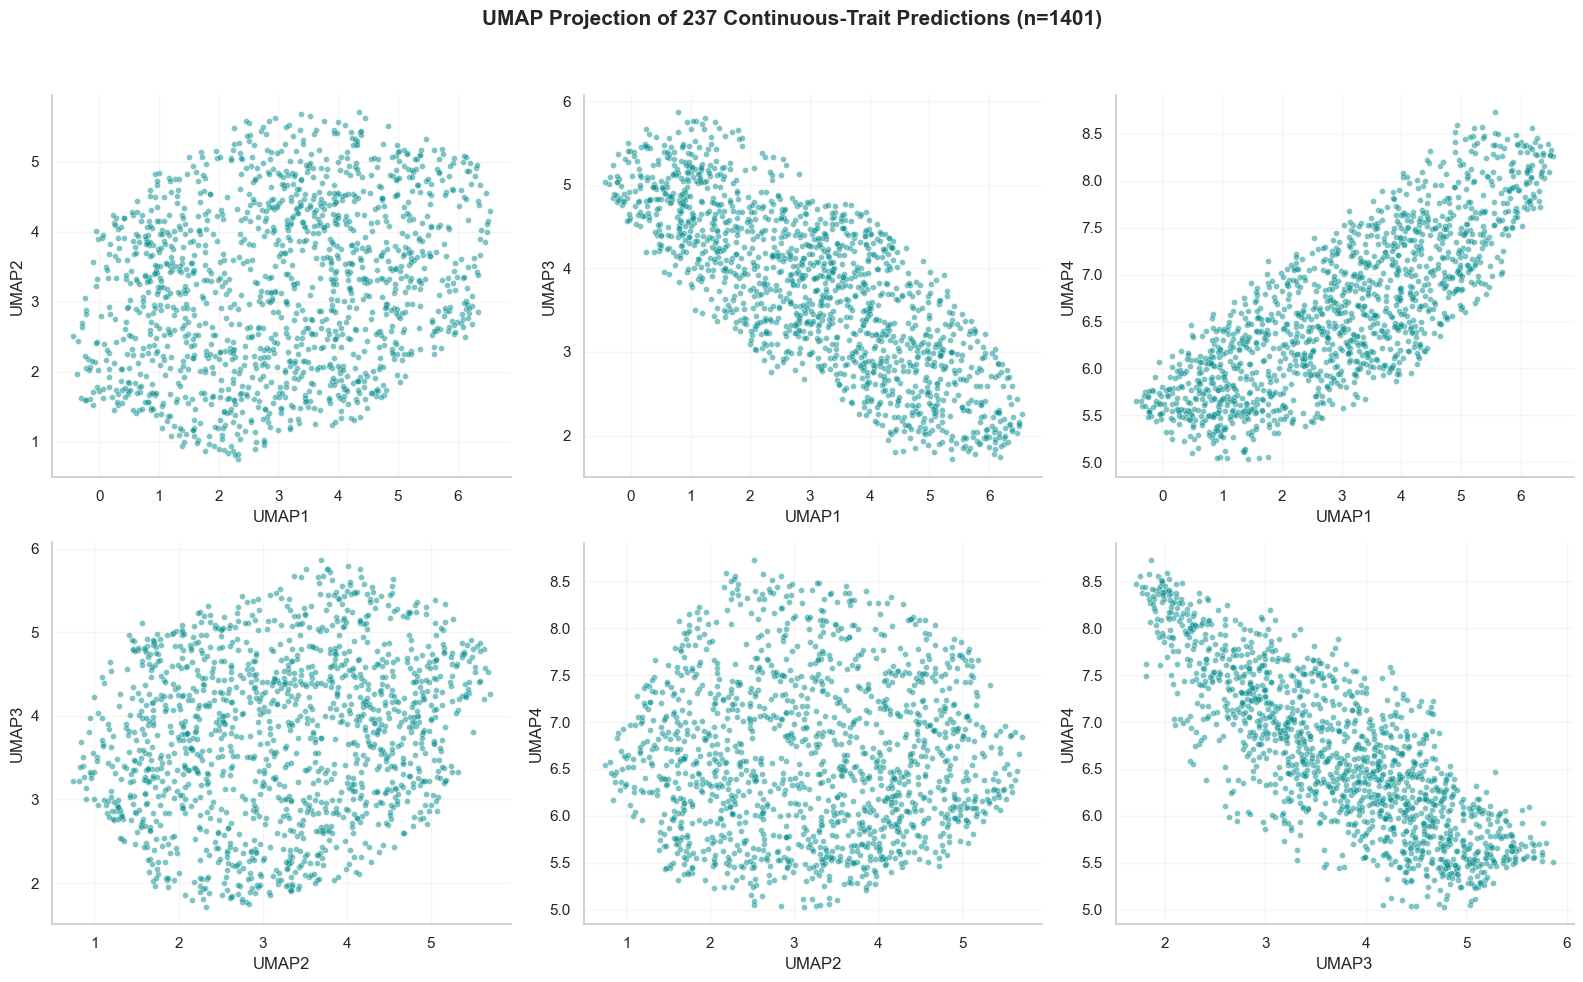

In [19]:
import umap

reducer = umap.UMAP(n_components=4, n_neighbors=30, min_dist=0.3,
                    metric="euclidean", random_state=42, n_jobs=1)

emb = reducer.fit_transform(X)
um_df = pd.DataFrame(emb, columns=[f"UMAP{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(um_df[f"UMAP{i}"], um_df[f"UMAP{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", color='darkcyan')
    
    ax.set_xlabel(f"UMAP{i}")
    ax.set_ylabel(f"UMAP{j}")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"UMAP Projection of {X_df.shape[1]} Continuous-Trait Predictions (n={len(um_df)})",
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*For reference: UMAP of the same predictions on the **Human Origins** dataset. UMAP picks up faint structure that PCA missed, but populations still overlap heavily. The two plots (PCA, UMAP) together tell a consistent story: the model's trait predictions carry only a faint trace of ancestry. UMAP is more sensitive to this kind of weak non-linear signal than PCA, which is exactly why running both is useful.*

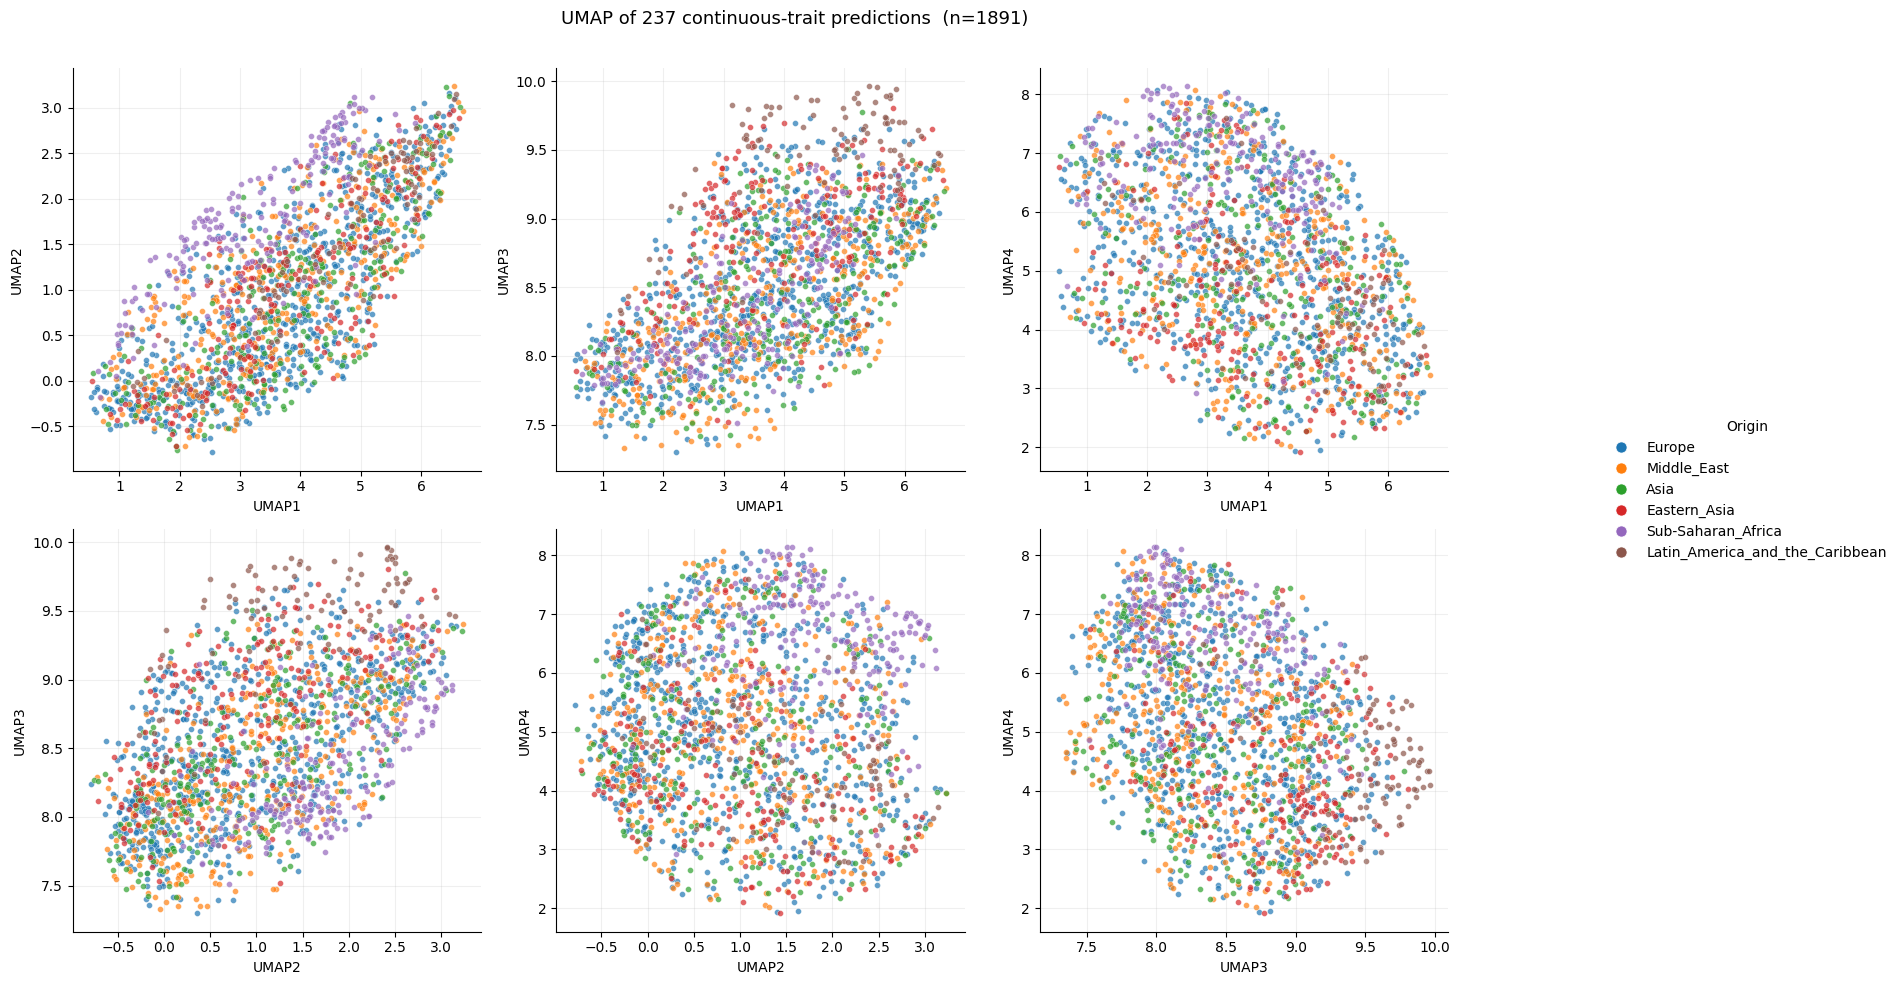